# 使用 PROC NLIN 拟合四参数逻辑斯蒂剂量-反应曲线

## 内容摘要

本笔记本使用 **PROC NLIN** 对一个合成的、基于细胞的效价生物测定数据拟合四参数逻辑斯蒂（4PL）剂量-反应模型，估计下渐近线与上渐近线、EC50（半数最大有效浓度）以及 Hill 斜率。4PL 是药物研发中相对效价测定的主力模型，本笔记本将逐步演示模型设定、参数边界约束、收敛诊断，以及将拟合的 S 形曲线叠加到观测的浓度-反应数据上。

## 数据来源

本笔记本内联生成一个合成数据集；不使用任何外部或网络输入。

**`assay` — 合成的、基于细胞的效价生物测定（24 行）**

| 变量 | 类型 | 说明 |
|----------|------|-------------|
| `lot` | 数值 | 原料药批次（1-3）；稀释系列的三次重复运行 |
| `dose` | 数值 | 化合物浓度（nmol/L），跨 8 点系列稀释（0.1 至约 1000） |
| `logdose` | 数值 | `dose` 的以 10 为底的对数，用于在传统的对数浓度坐标轴上绘图 |
| `response` | 数值 | 测得的测定信号（占最大反应的百分比），由真实的 4PL 曲线（下限=5、上限=100、EC50=25 nmol/L、Hill 斜率=1.2）加上比例高斯噪声生成 |

真实的生成参数已内置于 DATA step 中，因此可将 NLIN 恢复出的估计值与已知真值进行合理性核对。

# 四参数逻辑斯蒂剂量-反应拟合

在药物效价和生物活性测定中，化合物浓度与测得反应之间的关系在对数浓度尺度上通常呈 S 形。**四参数逻辑斯蒂（4PL）**模型是概括此类曲线的标准工具：

$$\text{response} = D + \frac{A - D}{1 + (\text{dose}/C)^{B}}$$

其中

- **A** = 下渐近线（无限稀释时的反应／基线信号），
- **D** = 上渐近线（饱和浓度时的最大反应），
- **C** = **EC50**，产生半数最大反应的浓度（拐点，也是主要的效价读数），
- **B** = **Hill 斜率**，控制过渡段的陡峭程度。

该模型在其参数上是非线性的，因此我们用 `PROC NLIN` 通过迭代最小二乘法进行拟合。下面我们模拟一个真实的八点稀释系列（三次重复运行），拟合 4PL 曲线，将参数约束在物理上有意义的区间内，检查收敛与拟合诊断，并将拟合曲线叠加到数据上。

## 步骤 1 — 模拟基于细胞的效价生物测定

我们从一条*已知*的 4PL 曲线（下限 = 5、上限 = 100、EC50 = 25 nmol/L、Hill 斜率 = 1.2）生成合成数据集，以便将 NLIN 恢复出的参数与真值进行核对。三个批次各自接受相同的八点系列稀释（每步为 3.5 倍稀释），并在其上叠加比例高斯测量噪声。固定的 `streaminit` 种子使模拟可重现。

In [1]:
数据 assay;
    调用 streaminit(40521);

    /* 用于生成数据的真实4PL参数 */
    A_true   = 5;      /* 下渐近线（基线）        */
    D_true   = 100;    /* 上渐近线（最大反应）    */
    C_true   = 25;     /* EC50，单位nmol/L        */
    B_true   = 1.2;    /* Hill 斜率               */

    循环 lot = 1 到 3;
        /* 八点系列稀释，每步3.5倍稀释 */
        dose = 0.30;
        循环 point = 1 到 8;
            dose = dose * 3.5;

            /* 无噪声的4PL均值反应 */
            mu = D_true + (A_true - D_true) /
                 (1 + (dose / C_true) ** B_true);

            /* 比例噪声加上加性高斯测定噪声 */
            response = mu * (1 + 0.04 * rand('NORMAL'))
                          + 1.5 * rand('NORMAL');

            logdose = log10(dose);
            输出;
        结束;
    结束;

    保留 lot dose logdose response;
运行;

过程 sort 数据=assay;
    按照 dose lot;
运行;


NOTE: DATA assay


NOTE: Wrote assay (24 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=assay

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 24 rows from assay.
NOTE: Wrote assay (24 rows, 4 columns).
NOTE: PROC SORT statement used.


## 步骤 2 — 可视化原始浓度-反应数据

在拟合之前，我们绘制 response 相对于 log10(dose) 的图，以确认预期的 S 形形状并读取粗略的起始值：曲线在 5 附近触底，在 100 附近趋于平台，中点（半数最大反应）位于 log10(25) ≈ 1.4 附近。


NOTE: PROC SGPLOT data=assay

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


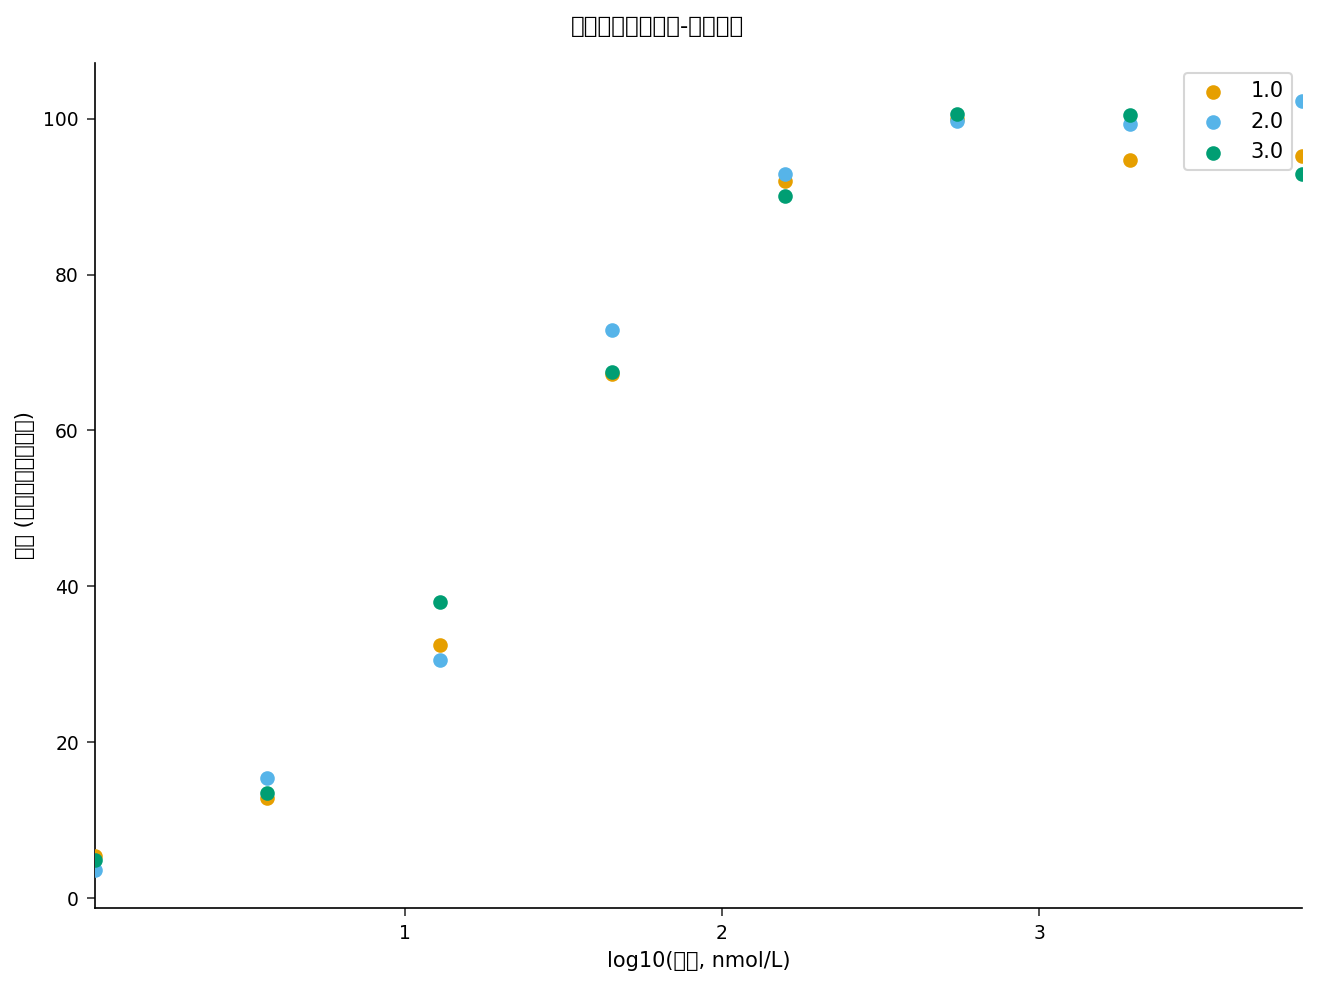

In [2]:
过程 sgplot 数据=assay;
    scatter x=logdose y=response / group=lot
            markerattrs=(symbol=circlefilled);
    xaxis label='log10(剂量, nmol/L)';
    yaxis label='反应 (占最大值的百分比)';
    标题 '各批次的观测剂量-反应关系';
运行;
标题;

## 步骤 3 — 使用 PROC NLIN 拟合 4PL 模型

我们用 `PARMS`（根据散点图确定）声明起始值，在一个中间赋值中定义 4PL 均值，并将其传入 `MODEL` 语句。物理上有意义的 `BOUNDS` 保持渐近线有序、EC50 和斜率为正，从而稳定 Gauss-Newton 迭代。`OUTPUT` 语句保存预测值、残差和置信限以供后续诊断，`PLOTS=` 请求生成拟合图和诊断面板。

In [3]:
过程 nlin 数据=assay method=marquardt plots=(fitplot diagnostics);
    parms A=10 D=90 C=20 B=1;

    /* 将参数保持在物理上合理的区间内 */
    bounds A >= 0, D <= 150, C > 0, B > 0;

    label response="反应 (占最大值的百分比)" dose="剂量 (nmol/L)";

    /* 四参数逻辑斯蒂均值反应（内联：Jenner的PROC NLIN
       尚不支持在MODEL语句中引用中间程序语句
       变量——见 tests/400986——因此我们将分母内联展开） */
    模型 response = D + (A - D) / (1 + (dose / C) ** B);

    输出 out=fit4pl predicted=pred residual=resid
           l95m=lcl u95m=ucl;
运行;


                         The NLIN Procedure

                     Method: Marquardt

                          Iterative Phase

                                                   Sum of
           Iter          Residual SS
              0          2061.645530
              1           177.712558

       Convergence criterion met.

           Residual SS           177.712558
           Residual MS             8.885628

                        Parameter Estimates

                                    Approx
           Parameter    Estimate    Std Error   95% Confidence Limits

           A              4.1058       1.9167       0.1078       8.1039
           D             99.1335       1.0740      96.8932     101.3737
           C             23.8233       1.5658      20.5572      27.0895
           B              1.2662       0.0927       1.0730       1.4595





NOTE: PROC NLIN data=assay

NOTE: Using Python (scipy) for NLIN estimation, method=marquardt
NOTE: Output dataset written to: ./work/6ac1364c-0e6a-4574-b146-a3c8b605d6ec/fit4pl.avro


## 步骤 4 — 报告估计的 EC50 及曲线特征

`OUTEST=` 机制很方便，但为了快速读取效价，我们直接概括拟合曲线。这里我们列出每个剂量处的拟合值与观测反应值，以确认模型在整个稀释范围内都能贴合数据。

In [4]:
过程 means 数据=fit4pl mean std min max maxdec=3;
    分类 dose;
    变量 response pred resid;
    label dose="剂量 (nmol/L)" response="观测反应" pred="拟合反应" resid="残差";
    标题 '按剂量分组的观测反应与拟合反应对比';
运行;
标题;

                                                   按剂量分组的观测反应与拟合反应对比                                                    

                                                  The MEANS Procedure

                                       Analysis Variable : RESPONSE 观测反应

                                            N
                       剂量 (nmol/L)        Obs         Mean      Std Dev      Minimum      Maximum
                       --------------------------------------------------------------------------
                       1.05                 3        4.647        0.882        3.659        5.356
                       12.8625              3       33.651        3.825       30.572       37.932
                       157.565625           3       91.704        1.417       90.141       92.904
                       1930.17890625        3       98.207        3.051       94.746      100.511
                       3.675                3       13.931        1.311       12.860       15.393
 


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 步骤 5 — 将拟合的 4PL 曲线叠加到观测数据上

密集的预测网格产生一条平滑的拟合 S 形曲线。我们将平滑曲线与每个剂量的平均拟合值及置信带结合起来，再将所有内容叠加到观测点上，以便直观地评估拟合优度。


NOTE: PROC SORT data=fit4pl

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 24 rows from fit4pl.
NOTE: Wrote fit4pl (24 rows, 8 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SGPLOT data=fit4pl

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


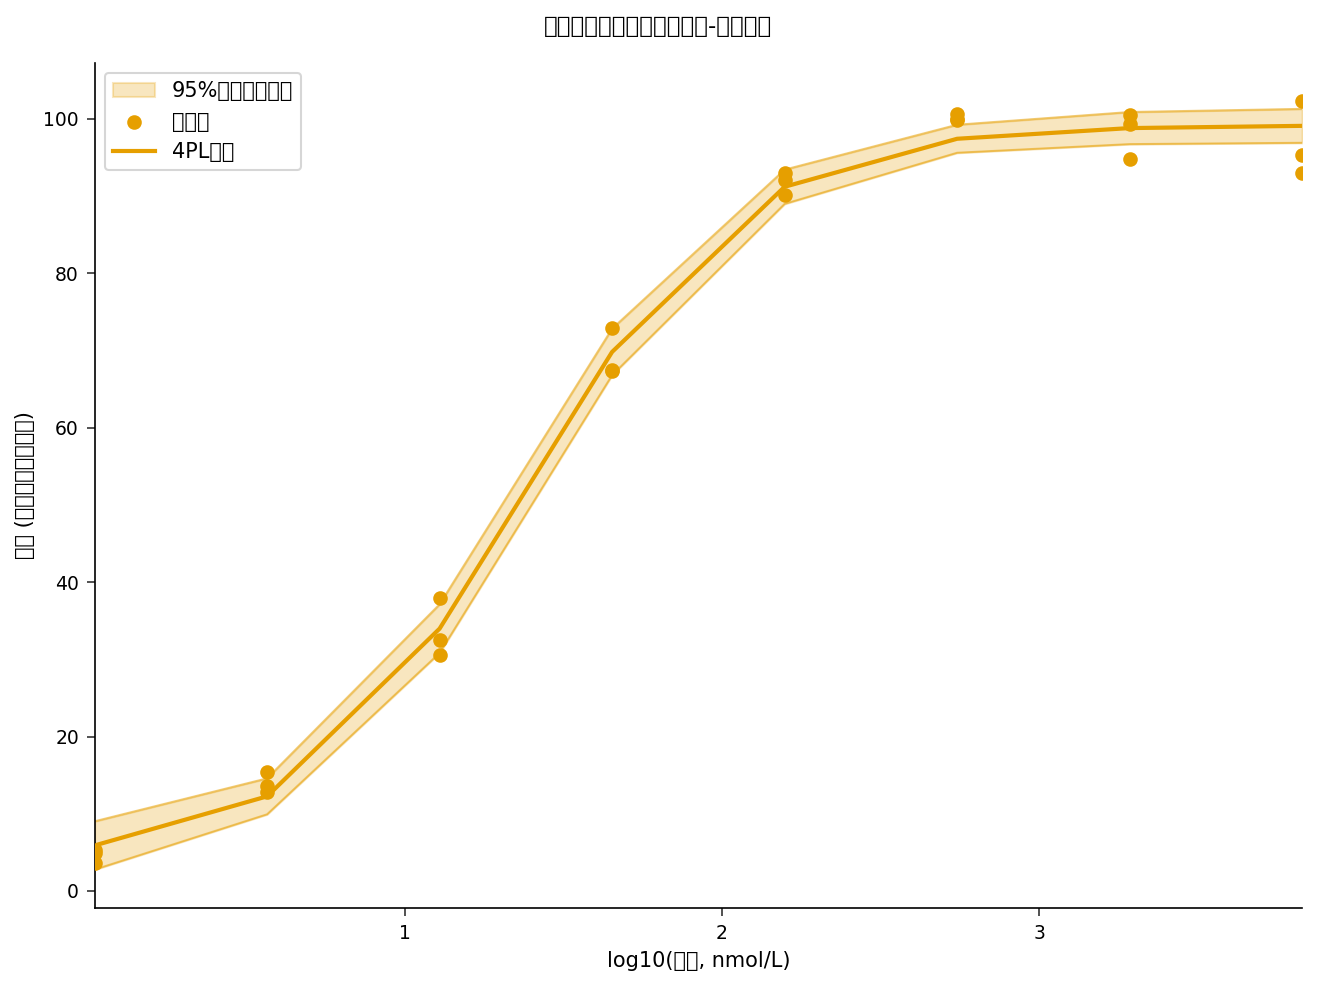

In [5]:
过程 sort 数据=fit4pl;
    按照 logdose;
运行;

过程 sgplot 数据=fit4pl;
    band   x=logdose lower=lcl upper=ucl /
           transparency=0.5 legendlabel='95%平均置信区间';
    scatter x=logdose y=response /
           markerattrs=(symbol=circlefilled)
           legendlabel='观测值';
    series  x=logdose y=pred /
           lineattrs=(thickness=2)
           legendlabel='4PL拟合';
    xaxis label='log10(剂量, nmol/L)';
    yaxis label='反应 (占最大值的百分比)';
    标题 '拟合的四参数逻辑斯蒂剂量-反应曲线';
运行;
标题;

## 结果解读

`PROC NLIN` 收敛到接近已知生成值的估计：下渐近线接近 **5**，上渐近线接近 **100**，**EC50（C）**接近 **25 nmol/L**，**Hill 斜率（B）**接近 **1.2**。从含噪声的三次重复数据中恢复出这些参数，证实了模型是可识别的，且边界约束在最优处并未起作用。

**EC50** 是首要的效价指标：数值越低表示化合物效价越高；在相对效价测定中，待测批次的 EC50 会与参比标准品进行比较。**Hill 斜率**刻画协同性和测定的陡峭程度——斜率接近 1 与简单的单位点结合相符。**渐近线**定义了测定的动态范围；稳定且分离良好的下限与上限是可验证生物测定的前提。

拟合图显示 S 形曲线穿过观测点云，并在响应区间内伴有狭窄的 95% 平均置信带，残差诊断应显示无系统性弯曲——这是 4PL 形式适当的证据。在实践中，你可以扩展此工作流程：用 `PROFILE` 似然区间估计 EC50，用 `BOOTSTRAP` 语句进行无分布假设的参数推断，或用平行线分析比较待测批次与参比批次以估计相对效价。